# SafeDPMSolver — Training + Live Sampling

Trains the VE-SDE score model on 2D trajectory data from the
**MPD dataset** (Carvalho et al., IROS 2023) and runs **basic ancestral sampling**
(Euler-Maruyama reverse SDE — not DPM-Solver) after every epoch, visualising results inline.

Trajectories were pre-generated by RRTConnect + GPMP2 in 2D point-mass environments
with circular obstacles (`EnvSimple2D`, `EnvNarrowPassageDense2D`, `EnvDense2D`).
No MuJoCo, d4rl, or torch_robotics required — we load the raw `.pt` files directly.

In [29]:
import sys, os, copy, math, time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

# Add the parent of SafeDPMSolver/ so that 'import SafeDPMSolver' works
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from SafeDPMSolver.models.score_net import ScoreNet
from SafeDPMSolver.models.ve_diffusion import VEDiffusion

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name()}')

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 1. Configuration

In [30]:
# ---- Trajectory shape ----
T_STEPS = 64        # waypoints per trajectory

# ---- Model (Temporal U-Net, MPD-style) ----
UNET_INPUT_DIM        = 32
DIM_MULTS             = (1, 2, 4)
TIME_EMB_DIM          = 32
CONDITIONING_EMB_DIM  = 4      # cat(x_start, x_goal) = 4-dim

# ---- Noise schedule (VE-SDE) ----
SIGMA_MIN  = 0.01
SIGMA_MAX  = 10.0
N_LEVELS   = 1000              # discrete levels during training

# ---- Training (MPD-matched) ----
BATCH_SIZE       = 128
LR               = 3e-4
EMA_DECAY        = 0.995
EMA_START_STEP   = 1_000
EMA_UPDATE_EVERY = 10
TOTAL_STEPS      = 100_000
LOG_EVERY        = 1_000       # log + visualise every N steps

# ---- Sampling ----
N_SAMPLE_STEPS = 25            # MPD uses 25
N_SAMPLES_VIS  = 16            # trajectories for waypoint scatter
N_TRAJ_VIS     = 5             # trajectories drawn as lines

## 2. MPD Dataset

Loads pre-generated trajectories from the [MPD repository](https://github.com/joaoamcarvalho/mpd-public)
(Carvalho et al., IROS 2023). Trajectories were produced by RRTConnect + GPMP2 in 2D point-mass environments
with circular obstacles.

Each `.pt` file holds `[20 trajs × 64 waypoints × 4 dims (x, y, vx, vy)]`.  
We use only `(x, y)` and emit one `(state, x_start, x_goal)` per waypoint — matching our ScoreNet format.

Available environments (set `MPD_ENV` below):
- `EnvSimple2D-RobotPointMass`
- `EnvNarrowPassageDense2D-RobotPointMass`
- `EnvDense2D-RobotPointMass`

[MPDTrajectoryDataset]  env=EnvSimple2D-RobotPointMass
  10,000 trajectories  |  shape per sample: (64, 2)


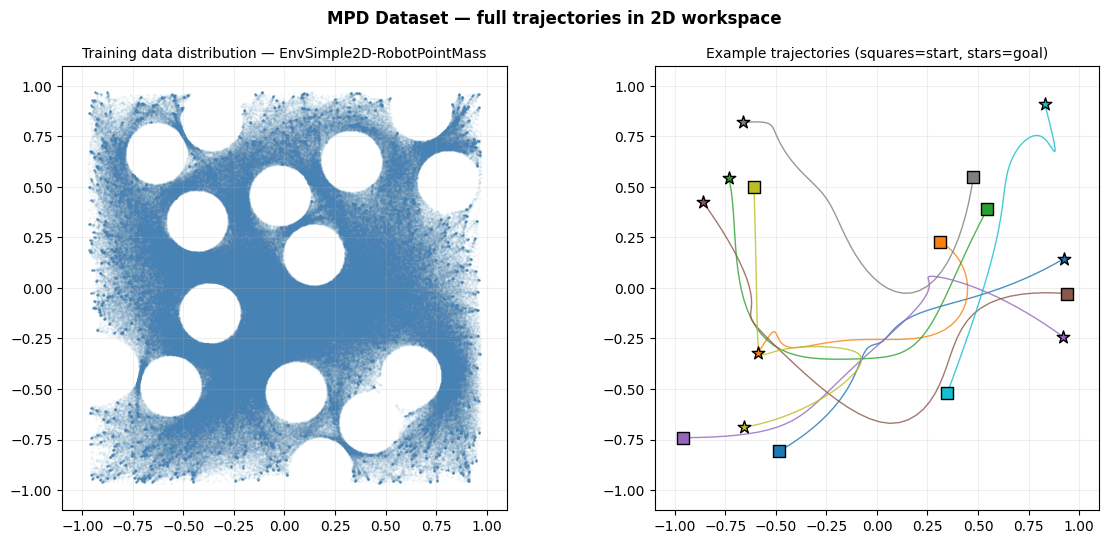

In [31]:
# ---- Path to MPD data (edit if you moved it) ----
MPD_DATA_ROOT = r'C:\Users\Owner\Downloads\MPD\mpd-public\data_trajectories'
MPD_ENV       = 'EnvSimple2D-RobotPointMass'


class MPDTrajectoryDataset(Dataset):
    """
    Loads MPD pre-generated trajectories as complete sequences.

    Each trajs-free.pt file: [n_trajs, 64, 4]  (x, y, vx, vy).
    We use only (x, y) and return one full trajectory [T_STEPS, 2] per sample,
    along with its start [2] and goal [2].
    """

    def __init__(self, env_dir: str, max_contexts: int = None):
        contexts = sorted(
            [d for d in os.listdir(env_dir) if os.path.isdir(os.path.join(env_dir, d))],
            key=int,
        )
        if max_contexts is not None:
            contexts = contexts[:max_contexts]

        trajs_l, starts_l, goals_l = [], [], []

        for c in contexts:
            pt_file = os.path.join(env_dir, c, 'trajs-free.pt')
            if not os.path.exists(pt_file):
                continue
            trajs = torch.load(pt_file, map_location='cpu')[..., :2].float()  # [n, 64, 2]
            for traj in trajs:
                trajs_l.append(traj)              # [64, 2]
                starts_l.append(traj[0])          # [2]
                goals_l.append(traj[-1])          # [2]

        self.trajs  = torch.stack(trajs_l)    # [N, 64, 2]
        self.starts = torch.stack(starts_l)   # [N, 2]
        self.goals  = torch.stack(goals_l)    # [N, 2]

        print(f'[MPDTrajectoryDataset]  env={os.path.basename(env_dir)}')
        print(f'  {len(self.trajs):,} trajectories  |  shape per sample: {tuple(self.trajs[0].shape)}')

    def __len__(self):
        return len(self.trajs)

    def __getitem__(self, idx):
        return self.trajs[idx], self.starts[idx], self.goals[idx]


dataset = MPDTrajectoryDataset(
    env_dir=os.path.join(MPD_DATA_ROOT, MPD_ENV),
)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# Quick look
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

# Panel 1: all waypoints (unrolled) to reveal obstacle voids
all_pts = dataset.trajs.reshape(-1, 2).numpy()
axes[0].scatter(all_pts[:, 0], all_pts[:, 1],
                s=0.3, alpha=0.07, c='steelblue', rasterized=True)
axes[0].set_xlim(-1.1, 1.1); axes[0].set_ylim(-1.1, 1.1)
axes[0].set_aspect('equal')
axes[0].set_title(f'Training data distribution — {MPD_ENV}', fontsize=10)
axes[0].grid(True, alpha=0.2)

# Panel 2: 8 example trajectories
colors = plt.cm.tab10(np.linspace(0, 1, 8))
for i, color in enumerate(colors):
    traj = dataset.trajs[i * 50].numpy()
    axes[1].plot(traj[:, 0], traj[:, 1], '-', color=color, alpha=0.8, linewidth=1.0)
    axes[1].scatter(*traj[0],  s=70,  color=color, edgecolors='k', zorder=5, marker='s')
    axes[1].scatter(*traj[-1], s=90,  color=color, edgecolors='k', zorder=5, marker='*')
axes[1].set_xlim(-1.1, 1.1); axes[1].set_ylim(-1.1, 1.1)
axes[1].set_aspect('equal')
axes[1].set_title('Example trajectories (squares=start, stars=goal)', fontsize=10)
axes[1].grid(True, alpha=0.2)

fig.suptitle('MPD Dataset — full trajectories in 2D workspace', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# Background points for later visualisation (reused across cells)
bg_idx = np.random.default_rng(0).choice(len(all_pts), size=20_000, replace=False)
bg_pts = all_pts[bg_idx]

In [32]:
env_func_path =  os.path.join(os.path.dirname(os.getcwd()), 'environments')
print(f'Appending to sys.path: {env_func_path}')
sys.path.append(env_func_path)

from circles_obstacles import load_mpd_deps, get_circles_from_env

load_mpd_deps()
ENV_CIRCLES = get_circles_from_env()

Appending to sys.path: c:\Users\Owner\SAFEDPMSolver\environments
Appending to sys.path: C:\Users\Owner\SAFE_DIFFUSION\mpd-public\deps


## 3. Model Setup

In [33]:
from SafeDPMSolver.models.score_net import TemporalUnet

score_net = TemporalUnet(
    state_dim=2,
    T_steps=T_STEPS,
    unet_input_dim=UNET_INPUT_DIM,
    dim_mults=DIM_MULTS,
    time_emb_dim=TIME_EMB_DIM,
    conditioning_embed_dim=CONDITIONING_EMB_DIM,
).to(device)

ve = VEDiffusion(
    model=score_net,
    sigma_min=SIGMA_MIN,
    sigma_max=SIGMA_MAX,
    n_levels=N_LEVELS,
).to(device)

ema_model = copy.deepcopy(score_net).to(device)
for p in ema_model.parameters():
    p.requires_grad_(False)

optimizer = torch.optim.Adam(score_net.parameters(), lr=LR)

n_params = sum(p.numel() for p in score_net.parameters())
cond_dim = TIME_EMB_DIM + CONDITIONING_EMB_DIM
print(f'TemporalUnet  |  {n_params:,} parameters')
print(f'U-Net dims    |  state={2} → {[UNET_INPUT_DIM * m for m in DIM_MULTS]}')
print(f'cond_dim      |  {TIME_EMB_DIM} (sigma) + {CONDITIONING_EMB_DIM} (start+goal) = {cond_dim}')
print(f'Horizon T     |  {T_STEPS} waypoints  |  device: {device}')

TemporalUnet  |  1,000,278 parameters
U-Net dims    |  state=2 → [32, 64, 128]
cond_dim      |  32 (sigma) + 4 (start+goal) = 36
Horizon T     |  64 waypoints  |  device: cuda


## 4. Basic Ancestral Sampler (Euler-Maruyama)

Standard reverse VE-SDE sampler — **not** DPM-Solver, no CBF.

At each step (sigma decreasing from $\sigma_{\max}$ to $\sigma_{\min}$):

$$x_{i+1} = x_i \;-\; \frac{\sigma_i^2 - \sigma_{i+1}^2}{\sigma_i}\,\epsilon_\theta(x_i, \sigma_i) \;+\; \sqrt{\sigma_i^2 - \sigma_{i+1}^2}\;z, \quad z \sim \mathcal{N}(0, I)$$

In [6]:
@torch.no_grad()
def ancestral_sample(
    model,
    ve_diffusion,
    x_start,              # [2] or [B, 2]
    x_goal,               # [2] or [B, 2]
    T_steps=64,
    n_steps=200,
    device='cpu',
    return_trajectory=False,
):
    """
    Ancestral sampler (Euler-Maruyama) for VE-SDE over full trajectories.

    Denoises a [B, T_steps, 2] tensor from pure noise down to a clean trajectory.

    Returns:
        x_final    : [B, T_steps, 2]
        trajectory : [n_steps+1, B, T_steps, 2]  (only if return_trajectory=True)
    """
    if x_start.dim() == 1:
        x_start = x_start.unsqueeze(0)
        x_goal  = x_goal.unsqueeze(0)
    B = x_start.shape[0]
    x_start = x_start.to(device)
    x_goal  = x_goal.to(device)

    sigmas = ve_diffusion.sigmas.to(device)
    N = ve_diffusion.n_levels
    indices   = torch.linspace(N, 0, n_steps + 1).long().clamp(0, N)
    sigma_seq = sigmas[indices]   # [n_steps+1], decreasing

    # Start from pure noise over the full trajectory
    x = torch.randn(B, T_steps, 2, device=device) * sigma_seq[0]

    trajectory = [x.clone()] if return_trajectory else None

    for i in range(n_steps):
        sig_cur  = sigma_seq[i]
        sig_next = sigma_seq[i + 1]

        if sig_next <= 0:
            break

        sig_batch = sig_cur.expand(B)
        eps_pred  = model(x, sig_batch, x_start, x_goal)   # [B, T, 2]

        delta_sig2 = sig_cur**2 - sig_next**2
        x = x - (delta_sig2 / sig_cur) * eps_pred

        if i < n_steps - 1:
            x = x + torch.sqrt(delta_sig2) * torch.randn_like(x)

        if return_trajectory:
            trajectory.append(x.clone())

    if return_trajectory:
        return x, torch.stack(trajectory, dim=0)   # [B,T,2], [steps+1,B,T,2]
    return x   # [B, T, 2]


print('Ancestral sampler defined.')

Ancestral sampler defined.


# DPM Solver 1 

In [34]:
@torch.no_grad()
def dpm_solver_1_sample(
    model,
    ve_diffusion,
    x_start,              # [2] or [B, 2]
    x_goal,               # [2] or [B, 2]
    T_steps=64,
    n_steps=25,
    device='cpu',
):
    """
    DPM-Solver-1 (first-order deterministic ODE) for VE-SDE.

    x_{i+1} = x_i - (sigma_i - sigma_{i+1}) * eps_theta(x_i, sigma_i)

    Returns:
        x_final : [B, T_steps, 2]
    """
    if x_start.dim() == 1:
        x_start = x_start.unsqueeze(0)
        x_goal  = x_goal.unsqueeze(0)
    B = x_start.shape[0]
    x_start = x_start.to(device)
    x_goal  = x_goal.to(device)

    sigmas = ve_diffusion.sigmas.to(device)
    N = ve_diffusion.n_levels
    indices   = torch.linspace(N, 0, n_steps + 1).long().clamp(0, N)
    sigma_seq = sigmas[indices]   # [n_steps+1], monotonically decreasing

    x = torch.randn(B, T_steps, 2, device=device) * sigma_seq[0]

    for i in range(n_steps):
        sig_cur  = sigma_seq[i]
        sig_next = sigma_seq[i + 1]

        sig_batch = sig_cur.expand(B)
        eps_pred  = model(x, sig_batch, x_start, x_goal)   # [B, T, 2]

        x = x - (sig_cur - sig_next) * eps_pred             # deterministic ODE step

    return x   # [B, T_steps, 2]


print('DPM-Solver-1 sampler defined.')

DPM-Solver-1 sampler defined.


## 5. Train + Sample + Visualise (live)

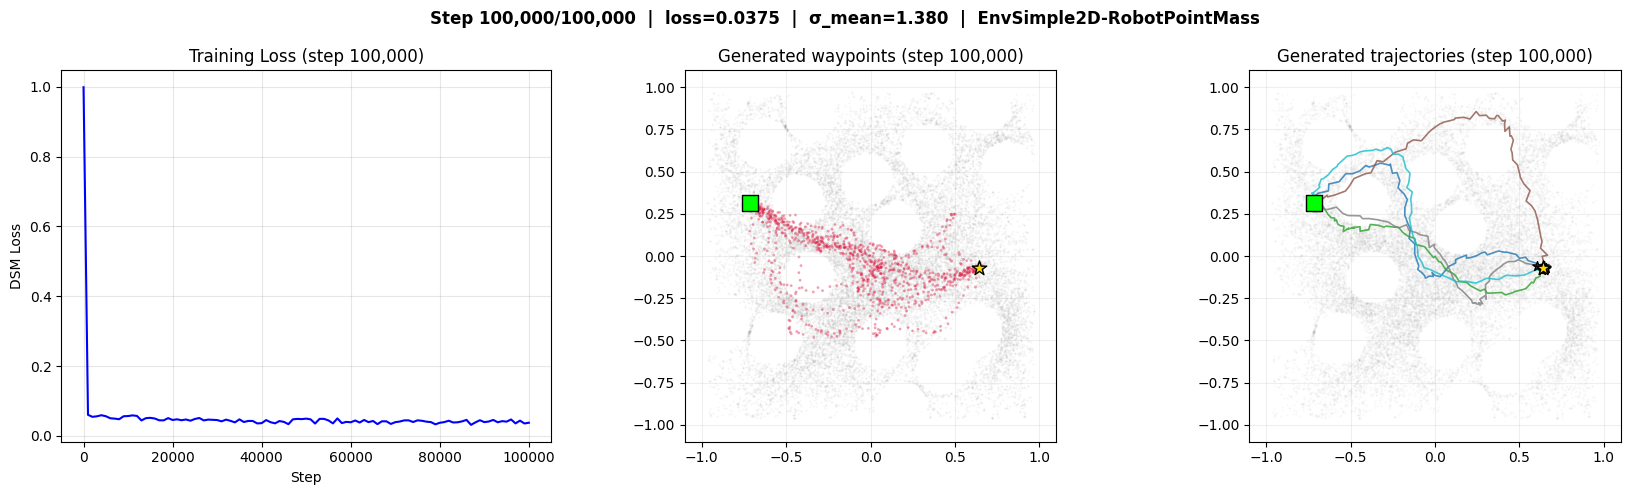


Training complete!


In [8]:
import itertools

rng_fix     = np.random.default_rng(7)
fixed_idx   = int(rng_fix.integers(0, len(dataset.trajs)))
fixed_start = dataset.starts[fixed_idx].to(device)
fixed_goal  = dataset.goals[fixed_idx].to(device)

loss_history  = []   # (step, loss) pairs
step          = 0
loader_iter   = itertools.cycle(loader)

print(f'Training for {TOTAL_STEPS:,} steps  |  batch={BATCH_SIZE}  |  lr={LR}  |  device={device}')
print(f'EMA: decay={EMA_DECAY}  start={EMA_START_STEP}  update_every={EMA_UPDATE_EVERY}')
print('=' * 70)

while step < TOTAL_STEPS:
    # ---- Training step ----
    score_net.train()
    x, xs, xg = next(loader_iter)
    x, xs, xg = x.to(device), xs.to(device), xg.to(device)

    loss, info = ve.loss(x, xs, xg)
    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(score_net.parameters(), 1.0)
    optimizer.step()

    # ---- EMA update ----
    if step >= EMA_START_STEP and step % EMA_UPDATE_EVERY == 0:
        with torch.no_grad():
            for p_ema, p in zip(ema_model.parameters(), score_net.parameters()):
                p_ema.data.mul_(EMA_DECAY).add_(p.data, alpha=1.0 - EMA_DECAY)

    step += 1

    # ---- Logging & visualisation ----
    if step % LOG_EVERY == 0 or step == 1:
        loss_history.append((step, info['loss']))
        ema_model.eval()

        xs_b = fixed_start.unsqueeze(0).expand(N_SAMPLES_VIS, -1)
        xg_b = fixed_goal.unsqueeze(0).expand(N_SAMPLES_VIS, -1)

        samples = dpm_solver_1_sample(
            ema_model, ve, xs_b, xg_b,
            T_steps=T_STEPS, n_steps=N_SAMPLE_STEPS, device=device,
        ).cpu().numpy()   # [N_SAMPLES_VIS, T, 2]

        xs_t = fixed_start.unsqueeze(0).expand(N_TRAJ_VIS, -1)
        xg_t = fixed_goal.unsqueeze(0).expand(N_TRAJ_VIS, -1)
        final_trajs, _ = ancestral_sample(
            ema_model, ve, xs_t, xg_t,
            T_steps=T_STEPS, n_steps=N_SAMPLE_STEPS, device=device,
            return_trajectory=True,
        )
        final_trajs = final_trajs.cpu().numpy()   # [N_TRAJ_VIS, T, 2]

        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(17, 5))
        s_np = fixed_start.cpu().numpy()
        g_np = fixed_goal.cpu().numpy()
        colors = plt.cm.tab10(np.linspace(0, 1, N_TRAJ_VIS))

        # Panel 1: loss curve
        steps_l, losses_l = zip(*loss_history)
        axes[0].plot(steps_l, losses_l, 'b-', linewidth=1.5)
        axes[0].set_xlabel('Step'); axes[0].set_ylabel('DSM Loss')
        axes[0].set_title(f'Training Loss (step {step:,})')
        axes[0].grid(True, alpha=0.3)

        # Panel 2: waypoint scatter
        scat_pts = samples.reshape(-1, 2)
        axes[1].scatter(bg_pts[:, 0], bg_pts[:, 1],
                        s=0.3, alpha=0.07, c='gray', rasterized=True)
        axes[1].scatter(scat_pts[:, 0], scat_pts[:, 1],
                        s=4, alpha=0.4, c='crimson', edgecolors='none')
        axes[1].scatter(*s_np, s=120, c='lime', edgecolors='black', zorder=5, marker='s')
        axes[1].scatter(*g_np, s=120, c='gold', edgecolors='black', zorder=5, marker='*')
        axes[1].set_xlim(-1.1, 1.1); axes[1].set_ylim(-1.1, 1.1)
        axes[1].set_aspect('equal')
        axes[1].set_title(f'Generated waypoints (step {step:,})')
        axes[1].grid(True, alpha=0.2)

        # Panel 3: trajectories as lines
        axes[2].scatter(bg_pts[:, 0], bg_pts[:, 1],
                        s=0.3, alpha=0.05, c='gray', rasterized=True)
        for j in range(N_TRAJ_VIS):
            traj_j = final_trajs[j]
            axes[2].plot(traj_j[:, 0], traj_j[:, 1], '-', color=colors[j], alpha=0.8, linewidth=1.2)
            axes[2].scatter(*traj_j[0],  s=40, color=colors[j], edgecolors='k', zorder=5, marker='s')
            axes[2].scatter(*traj_j[-1], s=50, color=colors[j], edgecolors='k', zorder=5, marker='*')
        axes[2].scatter(*s_np, s=120, c='lime', edgecolors='black', zorder=6, marker='s')
        axes[2].scatter(*g_np, s=120, c='gold', edgecolors='black', zorder=6, marker='*')
        axes[2].set_xlim(-1.1, 1.1); axes[2].set_ylim(-1.1, 1.1)
        axes[2].set_aspect('equal')
        axes[2].set_title(f'Generated trajectories (step {step:,})')
        axes[2].grid(True, alpha=0.2)

        fig.suptitle(
            f'Step {step:,}/{TOTAL_STEPS:,}  |  loss={info["loss"]:.4f}  |  σ_mean={info["sigma_mean"]:.3f}  |  {MPD_ENV}',
            fontsize=12, fontweight='bold',
        )
        plt.tight_layout(); plt.show()

print('\nTraining complete!')

In [9]:
CKPT_PATH = os.path.join(os.path.dirname(os.getcwd()), 'checkpoints', 've_unet_circles_100k.pt')
os.makedirs(os.path.dirname(CKPT_PATH), exist_ok=True)

# ---- Save ----
torch.save({
    'step':            step,
    'score_net':       score_net.state_dict(),
    'ema_model':       ema_model.state_dict(),
    'optimizer':       optimizer.state_dict(),
    'loss_history':    loss_history,
    # model config — needed to reconstruct the architecture on load
    'model_cfg': dict(
        state_dim=2, T_steps=T_STEPS,
        unet_input_dim=UNET_INPUT_DIM, dim_mults=DIM_MULTS,
        time_emb_dim=TIME_EMB_DIM, conditioning_embed_dim=CONDITIONING_EMB_DIM,
    ),
    've_cfg': dict(
        sigma_min=SIGMA_MIN, sigma_max=SIGMA_MAX, n_levels=N_LEVELS,
    ),
}, CKPT_PATH)
print(f'Saved checkpoint  →  {CKPT_PATH}  (step {step:,})')

Saved checkpoint  →  c:\Users\Owner\Diffuser\SafeDPMSolver\checkpoints\ve_unet_circles_100k.pt  (step 100,000)


In [35]:
# ---- Load ----
CKPT_PATH = os.path.join(os.path.dirname(os.getcwd()), 'checkpoints', 've_unet_circles_100k.pt')

ckpt = torch.load(CKPT_PATH, map_location=device)

# Rebuild model from saved config
score_net = TemporalUnet(**ckpt['model_cfg']).to(device)
ve        = VEDiffusion(model=score_net, **ckpt['ve_cfg']).to(device)
ema_model = copy.deepcopy(score_net).to(device)
for p in ema_model.parameters():
    p.requires_grad_(False)
optimizer = torch.optim.Adam(score_net.parameters(), lr=LR)

score_net.load_state_dict(ckpt['score_net'])
ema_model.load_state_dict(ckpt['ema_model'])
optimizer.load_state_dict(ckpt['optimizer'])
step         = ckpt['step']
loss_history = ckpt['loss_history']

print(f'Loaded checkpoint  ←  {CKPT_PATH}  (step {step:,})')
print(f'Resume training by re-running the train cell from step {step:,}')

Loaded checkpoint  ←  c:\Users\Owner\SAFEDPMSolver\checkpoints\ve_unet_circles_100k.pt  (step 100,000)
Resume training by re-running the train cell from step 100,000


## 6. Bonus: Sample from multiple (start, goal) pairs

In [ ]:
ema_model.eval()

rng2      = np.random.default_rng(99)
traj_idxs = rng2.choice(len(dataset.trajs), size=4, replace=False)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax_i, tidx in enumerate(traj_idxs):
    xs_i = dataset.starts[int(tidx)].to(device)
    xg_i = dataset.goals[int(tidx)].to(device)

    xs_b = xs_i.unsqueeze(0).expand(8, -1)
    xg_b = xg_i.unsqueeze(0).expand(8, -1)

    samps = ancestral_sample(
        ema_model, ve, xs_b, xg_b,
        T_steps=T_STEPS, n_steps=N_SAMPLE_STEPS, device=device,
    ).cpu().numpy()   # [8, T, 2]

    colors4 = plt.cm.tab10(np.linspace(0, 1, 8))
    axes[ax_i].scatter(bg_pts[:, 0], bg_pts[:, 1],
                       s=0.2, alpha=0.06, c='gray', rasterized=True)
    for j in range(8):
        axes[ax_i].plot(samps[j, :, 0], samps[j, :, 1],
                        '-', color=colors4[j], alpha=0.7, linewidth=1.0)
        axes[ax_i].scatter(*samps[j, 0],  s=30, color=colors4[j], edgecolors='k', zorder=5, marker='s')
        axes[ax_i].scatter(*samps[j, -1], s=40, color=colors4[j], edgecolors='k', zorder=5, marker='*')

    s_np_i = xs_i.cpu().numpy()
    g_np_i = xg_i.cpu().numpy()
    axes[ax_i].scatter(*s_np_i, s=120, c='lime', edgecolors='black', zorder=6, marker='s')
    axes[ax_i].scatter(*g_np_i, s=120, c='gold', edgecolors='black', zorder=6, marker='*')
    axes[ax_i].set_xlim(-1.1, 1.1); axes[ax_i].set_ylim(-1.1, 1.1)
    axes[ax_i].set_aspect('equal')
    axes[ax_i].set_title(f'Context {ax_i + 1}', fontsize=10)
    axes[ax_i].grid(True, alpha=0.2)

fig.suptitle(f'8 generated trajectories per context — {MPD_ENV}',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 6b. DPM-Solver-1: Sample from multiple (start, goal) pairs

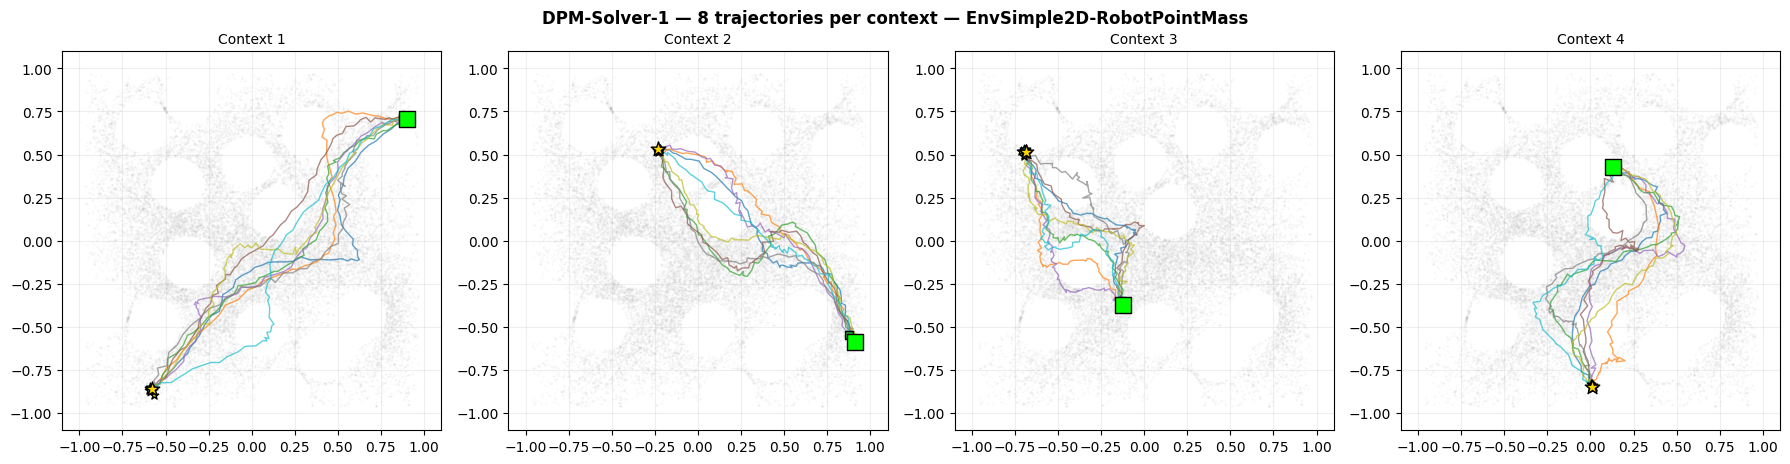

In [36]:
ema_model.eval()

rng3       = np.random.default_rng(42)
traj_idxs3 = rng3.choice(len(dataset.trajs), size=4, replace=False)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax_i, tidx in enumerate(traj_idxs3):
    xs_i = dataset.starts[int(tidx)].to(device)
    xg_i = dataset.goals[int(tidx)].to(device)

    xs_b = xs_i.unsqueeze(0).expand(8, -1)
    xg_b = xg_i.unsqueeze(0).expand(8, -1)

    samps = dpm_solver_1_sample(
        ema_model, ve, xs_b, xg_b,
        T_steps=T_STEPS, n_steps=5, device=device,
    ).cpu().numpy()   # [8, T, 2]

    colors4 = plt.cm.tab10(np.linspace(0, 1, 8))
    axes[ax_i].scatter(bg_pts[:, 0], bg_pts[:, 1],
                       s=0.2, alpha=0.06, c='gray', rasterized=True)
    for j in range(8):
        axes[ax_i].plot(samps[j, :, 0], samps[j, :, 1],
                        '-', color=colors4[j], alpha=0.7, linewidth=1.0)
        axes[ax_i].scatter(*samps[j, 0],  s=30, color=colors4[j], edgecolors='k', zorder=5, marker='s')
        axes[ax_i].scatter(*samps[j, -1], s=40, color=colors4[j], edgecolors='k', zorder=5, marker='*')

    s_np_i = xs_i.cpu().numpy()
    g_np_i = xg_i.cpu().numpy()
    axes[ax_i].scatter(*s_np_i, s=120, c='lime', edgecolors='black', zorder=6, marker='s')
    axes[ax_i].scatter(*g_np_i, s=120, c='gold', edgecolors='black', zorder=6, marker='*')
    axes[ax_i].set_xlim(-1.1, 1.1); axes[ax_i].set_ylim(-1.1, 1.1)
    axes[ax_i].set_aspect('equal')
    axes[ax_i].set_title(f'Context {ax_i + 1}', fontsize=10)
    axes[ax_i].grid(True, alpha=0.2)

fig.suptitle(f'DPM-Solver-1 — 8 trajectories per context — {MPD_ENV}',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 6c. Safe DPM-Solver-1 with Trajectory-Level CBF (Eq. 70)

Augments DPM-Solver-1 with a trajectory-level CBF safety correction derived in `SafeDPM/FullDerv.pdf`, Section 4.

**Update rule (eq. 70):**

$$x_{t_{i-1} \to t_i} = x_{t_{i-1}} - (\sigma_{t_{i-1}} - \sigma_{t_i})\,\epsilon_\theta - \Delta t \cdot \frac{\min\!\left(0,\; \nabla h_{t_{i-1}}^\top(\sigma_{t_{i-1}}-\sigma_{t_i})\epsilon_\theta + \alpha_0 h_{t_{i-1}}\right)}{\|\nabla h_{t_{i-1}}\|_2^2 + \rho^{-1} h_{t_{i-1}}^2}\,\nabla h_{t_{i-1}}$$

Where:
- $h(X_t)$ — trajectory-level CBF (two-level softmin over waypoints and obstacles)
- $\nabla h(X_t) \in \mathbb{R}^{T \times 2}$ — full trajectory gradient from `CBF/trajectory_cbf.py`
- $\rho = \max(0,\, \text{step} - n\_\text{steps}/2)$ — relaxation (zero for first half of denoising)
- $m_1$ — obstacle softmax weights $\alpha_{ij}$; $m_2$ — waypoint softmax weights $\sigma_i$

In [60]:
import sys
_cbf_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if _cbf_root not in sys.path:
    sys.path.insert(0, _cbf_root)

from SafeDPMSolver.CBF.trajectory_cbf import trajectory_cbf, grad_hXt_dXt, waypoint_cbf


def cbf_control_term(
    Xt,           # [T, 2]  current trajectory (single sample, no batch dim)
    eps_pred,     # [T, 2]  predicted noise for this trajectory
    sig_cur,      # float   sigma at the current denoising step
    sig_next,     # float   sigma at the next denoising step
    sigma_dot,    # float   σ̇ at the current denoising step
    step,     # int     loop counter: 0 = most noisy, n_steps-1 = cleanest
    step_next,
    n_steps,      # int     total denoising steps
    obstacles,    # [N, 3]  (px, py, r) in the same space as Xt
    k1=1.0,       # softmin temperature over obstacles  (m1 weights)
    k2=1.0,       # softmin temperature over waypoints  (m2 weights)
    alpha0=1.0,   # class-K linear gain  α(h) = alpha0 * h
    gamma_delta=0.0,
    eps=1e-8,
    verbose=False,
):
    """
    CBF control correction for a single trajectory [T, 2], eq. 70.

    Computes:
        rho       = max(0, step_idx - n_steps/2)      relaxation parameter
        h_val     = h(X_t)                            scalar CBF value
        grad_h    = grad_{X_t} h(X_t)                [T, 2]
        omega     = grad_h . (delta_sig * eps_pred) + alpha0 * h_val
        ctrl      = min(0, omega) / (||grad_h||^2 + rho^{-1} h^2) * grad_h

    Returns [T, 2].  The sampler subtracts this from x_new (eq. 70).
    When rho = 0 (second half of denoising) returns zeros — no correction applied.
    """
    print(f'Relaxation : {step - n_steps/2.0} step : {step} n_steps : {n_steps}')
    rho = max(0.0, step - n_steps/2.0)   # relaxation γ  (zero for second half)
    # print(f'step={step}, rho={rho:.3f}')
    # if rho < eps:
    #     return torch.zeros_like(Xt)

    h_val  = trajectory_cbf(Xt, obstacles, k1, k2, gamma_delta)   # scalar
    grad_h = grad_hXt_dXt(Xt, obstacles, k1, k2, gamma_delta)     # [T, 2]

    # ω = ∇h^T · (σ_{i-1} − σ_i) ε_θ + α₀ h
    delta_sig = sig_cur - sig_next                                  # positive scalar
    omega     = (grad_h * (sigma_dot * eps_pred)).sum() + alpha0 * h_val

    omega_neg = torch.clamp(omega, max=0.0)                         # min(0, ω)
    if rho > 0.0:
        denom     = (grad_h * grad_h).sum() + (1.0 / rho) * h_val ** 2 + eps
    else:
        denom     = (grad_h * grad_h).sum() + eps

    ctrl_vec = (omega_neg / denom) * grad_h

    if verbose:
        import pandas as pd

        delta_sig = sig_cur - sig_next

        df = pd.DataFrame({
            'grad_h_x':    grad_h[:, 0].cpu().numpy(),
            'grad_h_y':    grad_h[:, 1].cpu().numpy(),
            'eps_x':       eps_pred[:, 0].cpu().numpy(),
            'eps_y':       eps_pred[:, 1].cpu().numpy(),
            'sdot*eps_x':  (sigma_dot * eps_pred[:, 0]).cpu().numpy(),
            'sdot*eps_y':  (sigma_dot * eps_pred[:, 1]).cpu().numpy(),
            'gh·sdot·e':   (grad_h * sigma_dot * eps_pred).sum(dim=1).cpu().numpy(),
            'ctrl_x':      ctrl_vec[:, 0].cpu().detach().numpy(),
            'ctrl_y':      ctrl_vec[:, 1].cpu().detach().numpy(),
        })
        df.index.name = 'wp'

        print(f"\n{'='*60}")
        print(f" step={step}  rho={rho:.4f}  sigma_dot={sigma_dot:.6f}")
        print(f" h_val={h_val.item():.6f}  alpha0={alpha0:.4f}")
        print(f" omega={omega.item():.6f}  omega_neg={omega_neg.item():.6f}")
        print(f" denom={denom.item():.6f}")
        print(f"{'='*60}")
        pd.set_option('display.float_format', '{:.6f}'.format)
        pd.set_option('display.max_rows', len(df))
        print(df.to_string())
        print()

    return omega_neg.cpu(), (omega_neg / denom) * grad_h *(step - step_next)   # [T, 2]

print('cbf_control_term defined.')

cbf_control_term defined.


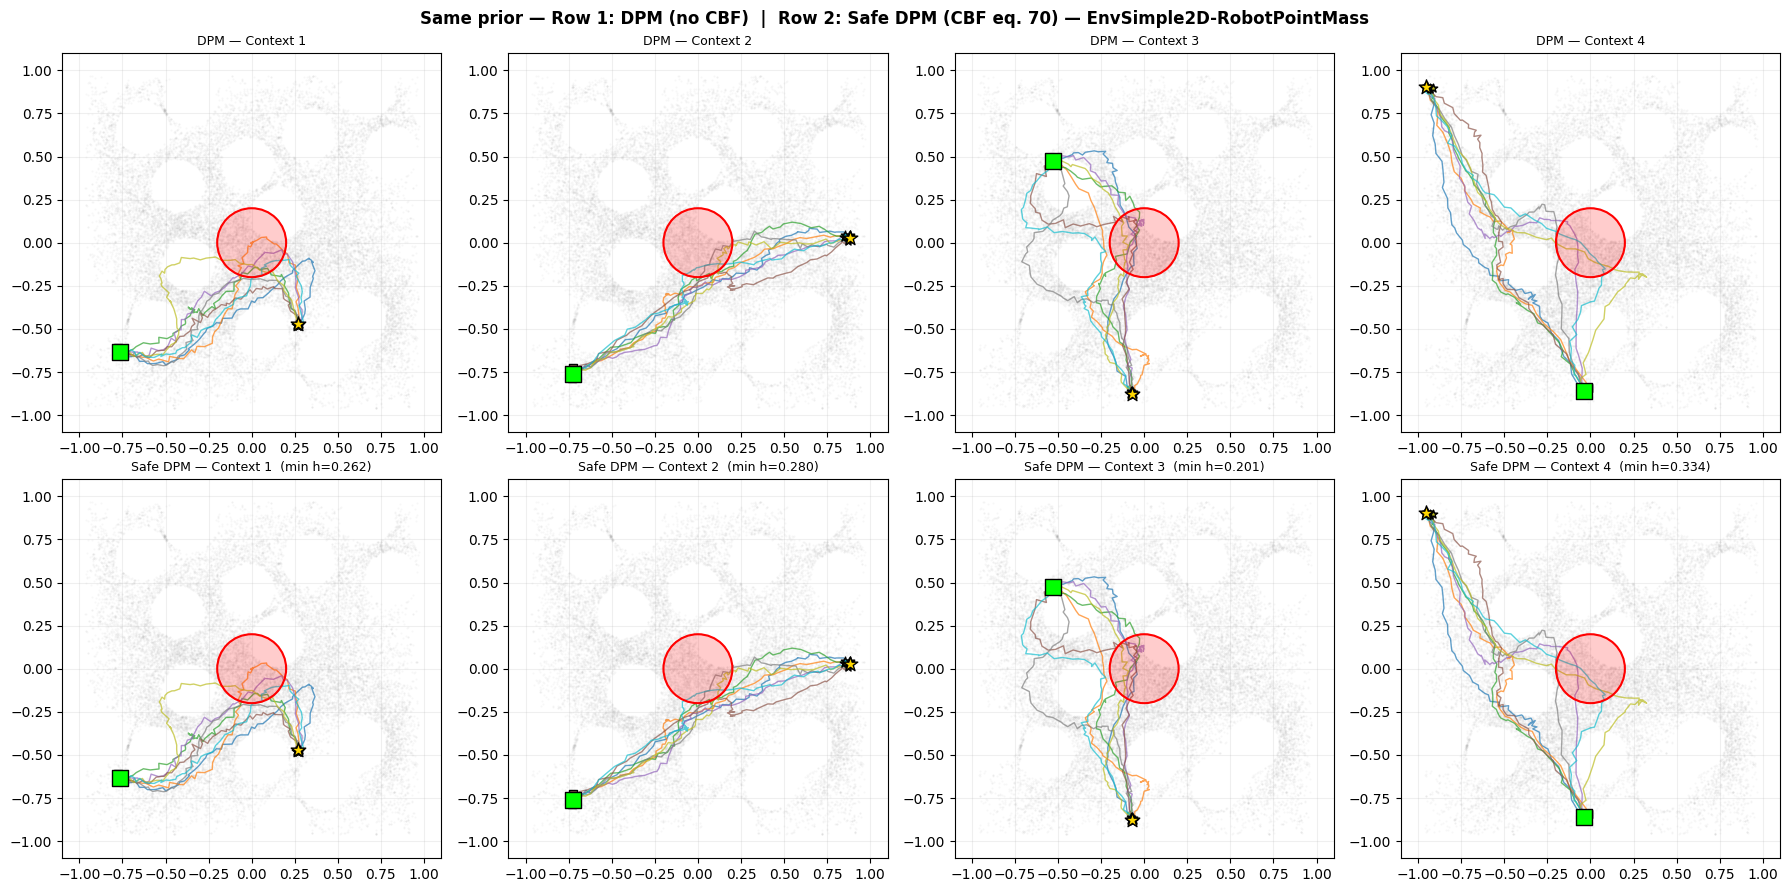

In [46]:
@torch.no_grad()
def dpm_solver_1_cbf_sample(
    model,
    ve_diffusion,
    x_start,              # [B, 2]  start conditions
    x_goal,               # [B, 2]  goal  conditions
    obstacles,            # [N, 3]  float tensor (px, py, r) — normalised space
    T_steps=64,
    n_steps=25,
    k1=1.0,               # softmin temperature over obstacles  (m1 weights)
    k2=1.0,               # softmin temperature over waypoints  (m2 weights)
    alpha0=1.0,           # class-K gain
    gamma_delta=0.0,      # distance margin added to d_ij
    x_init=None,          # [B, T, 2] pre-sampled prior; if None, sample fresh
    device='cpu',
):
    """
    DPM-Solver-1 with trajectory-level CBF safety correction (eq. 70).

    At each denoising step:
        x_new = x - (sig_cur - sig_next) * eps_theta            # base ODE step
              - cbf_control_term(x, eps, ...)                   # safety correction

    The CBF correction is zero for the first half of denoising (rho = 0) and
    grows linearly for the second half, steering trajectories away from obstacles.

    Args:
        obstacles : [N, 3] tensor of (px, py, r).  Pass torch.zeros(0, 3) to
                    disable safety correction (recovers plain dpm_solver_1_sample).
        x_init    : optional [B, T, 2] tensor — shared prior for controlled comparison.
                    When provided, both CBF and no-CBF runs start from the same noise.

    Returns:
        x : [B, T_steps, 2]
    """
    if x_start.dim() == 1:
        x_start = x_start.unsqueeze(0)
        x_goal  = x_goal.unsqueeze(0)
    B = x_start.shape[0]

    x_start   = x_start.to(device)
    x_goal    = x_goal.to(device)
    obstacles = obstacles.to(device)

    sigmas  = ve_diffusion.sigmas.to(device)
    N_lvl   = ve_diffusion.n_levels
    indices   = torch.linspace(N_lvl, 0, n_steps + 1).long().clamp(0, N_lvl)
    sigma_seq = sigmas[indices]   # [n_steps+1], monotonically decreasing

    if x_init is not None:
        x = x_init.to(device).clone()
    else:
        x = torch.randn(B, T_steps, 2, device=device) * sigma_seq[0]

    has_obstacles = obstacles.shape[0] > 0

    for step in range(n_steps):
        sig_cur  = sigma_seq[step]
        sig_next = sigma_seq[step + 1]

        eps_pred = model(x, sig_cur.expand(B), x_start, x_goal)   # [B, T, 2]

        # --- Base DPM-Solver-1 step -------------------------------------------
        x_new = x - (sig_cur - sig_next) * eps_pred

        # --- CBF correction (per sample in batch) -----------------------------
        if has_obstacles:
            for b in range(B):
                omega_val, ctrl = cbf_control_term(
                    x[b], eps_pred[b],
                    sig_cur.item(), sig_next.item(), ve_diffusion.sigma_dot(sig_cur).item(),
                    indices[step], indices[step + 1], n_steps,
                    obstacles, k1, k2, alpha0, gamma_delta, verbose=False,
                )
                x_new[b] = x_new[b] - ctrl   # eq. 70: subtract control term

        x = x_new

    return x   # [B, T_steps, 2]


# ---------------------------------------------------------------------------
# Demo: 4 contexts — DPM vs Safe DPM from the SAME prior
# Row 0: plain DPM-Solver-1 (no CBF)
# Row 1: Safe DPM-Solver-1  (CBF eq. 70)
# Same trajectory colour = same prior sample, different sampler
# ---------------------------------------------------------------------------
ema_model.eval()

OBSTACLES  = torch.tensor([[0.0, 0.0, 0.2]])   # one obstacle at centre, r=0.2
sigma_max  = ve.sigmas[ve.n_levels].item()      # prior scale = sigma at step 0

rng_cbf  = np.random.default_rng(55)
cbf_idxs = rng_cbf.choice(len(dataset.trajs), size=4, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for ax_i, tidx in enumerate(cbf_idxs):
    xs_i = dataset.starts[int(tidx)].to(device)
    xg_i = dataset.goals[int(tidx)].to(device)
    xs_b = xs_i.unsqueeze(0).expand(8, -1)
    xg_b = xg_i.unsqueeze(0).expand(8, -1)

    # 1. Sample shared prior
    x_init = torch.randn(8, T_STEPS, 2, device=device) * sigma_max

    # 2. Plain DPM (no CBF) — pass empty obstacles to short-circuit corrections
    samps_dpm = dpm_solver_1_cbf_sample(
        ema_model, ve, xs_b, xg_b,
        obstacles=torch.zeros(0, 3),
        T_steps=T_STEPS, n_steps=25,
        x_init=x_init, device=device,
    ).cpu().numpy()   # [8, T, 2]

    # 3. Safe DPM (with CBF) — same prior
    samps_safe = dpm_solver_1_cbf_sample(
        ema_model, ve, xs_b, xg_b,
        obstacles=OBSTACLES,
        T_steps=T_STEPS, n_steps=25,
        k1=1.0, k2=1.0, alpha0=1000.0, gamma_delta=0.05,
        x_init=x_init, device=device,
    ).cpu().numpy()   # [8, T, 2]

    # Report min h value across safe batch
    obs_t = OBSTACLES.to(device)
    min_h = min(
        trajectory_cbf(
            torch.tensor(samps_safe[b], device=device),
            obs_t, k1=1.0, k2=1.0, gamma_delta=0.05,
        ).item()
        for b in range(8)
    )

    colors8 = plt.cm.tab10(np.linspace(0, 1, 8))

    for row, (samps, title) in enumerate([
        (samps_dpm,  f'DPM — Context {ax_i + 1}'),
        (samps_safe, f'Safe DPM — Context {ax_i + 1}  (min h={min_h:.3f})'),
    ]):
        ax = axes[row, ax_i]
        ax.scatter(bg_pts[:, 0], bg_pts[:, 1],
                   s=0.2, alpha=0.06, c='gray', rasterized=True)
        for j in range(8):
            ax.plot(samps[j, :, 0], samps[j, :, 1],
                    '-', color=colors8[j], alpha=0.7, linewidth=1.0)
            ax.scatter(*samps[j, 0],  s=30, color=colors8[j], edgecolors='k', zorder=5, marker='s')
            ax.scatter(*samps[j, -1], s=40, color=colors8[j], edgecolors='k', zorder=5, marker='*')

        # Obstacle circle
        for px, py, r in OBSTACLES.numpy():
            ax.add_patch(plt.Circle((px, py), r, color='red', alpha=0.2,  zorder=4))
            ax.add_patch(plt.Circle((px, py), r, color='red', fill=False, linewidth=1.5, zorder=5))

        ax.scatter(*xs_i.cpu().numpy(), s=120, c='lime', edgecolors='black', zorder=6, marker='s')
        ax.scatter(*xg_i.cpu().numpy(), s=120, c='gold', edgecolors='black', zorder=6, marker='*')
        ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
        ax.set_aspect('equal')
        ax.set_title(title, fontsize=9)
        ax.grid(True, alpha=0.2)

fig.suptitle(
    f'Same prior — Row 1: DPM (no CBF)  |  Row 2: Safe DPM (CBF eq. 70) — {MPD_ENV}',
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
plt.show()

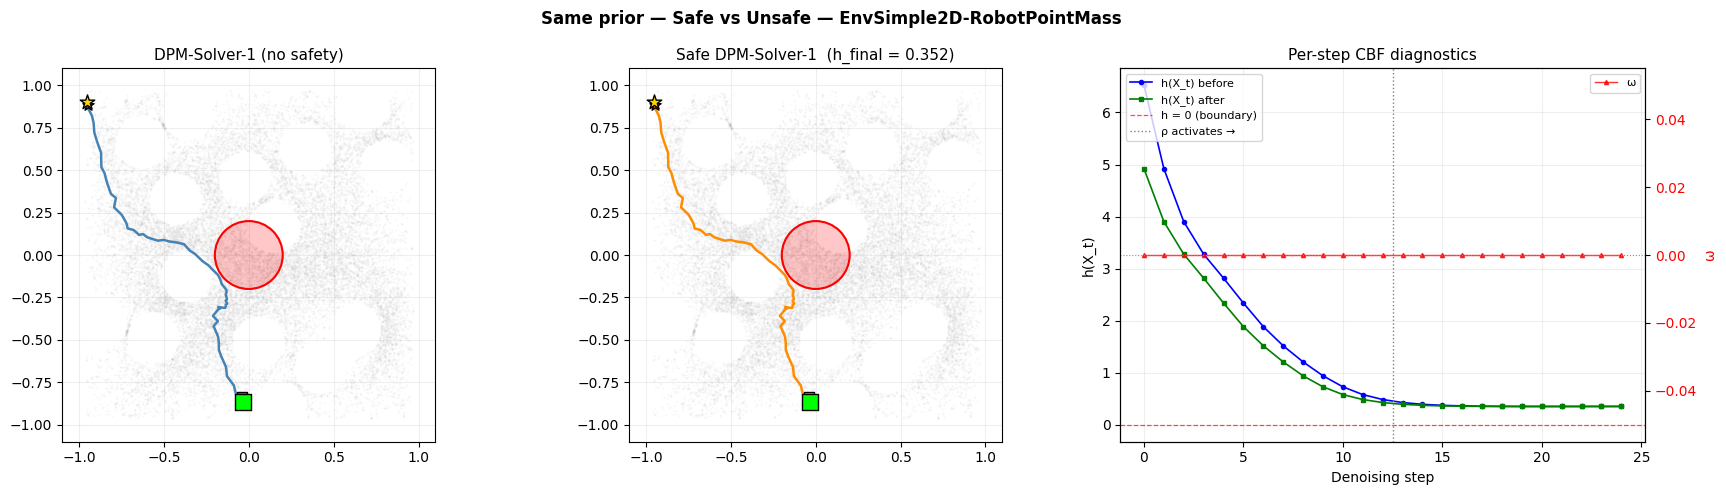

In [47]:
# ── Config ────────────────────────────────────────────────────────────────────
N_STEPS_CBF  = 25
K1, K2       = 1.0, 1.0
ALPHA0       = 1.0
GAMMA_DELTA  = 0.0

OBSTACLES_DEMO = torch.tensor([[0.0, 0.0, 0.2]], device=device)  # (px, py, r)

# ── Pick one start/goal pair ──────────────────────────────────────────────────
rng_cbf = np.random.default_rng(55)
tidx    = int(rng_cbf.integers(0, len(dataset.trajs)))
xs_i    = dataset.starts[tidx].unsqueeze(0).to(device)   # [1, 2]
xg_i    = dataset.goals[tidx].unsqueeze(0).to(device)    # [1, 2]

# ── Build sigma schedule ──────────────────────────────────────────────────────
indices_cbf = torch.linspace(ve.n_levels, 0, N_STEPS_CBF + 1).long().clamp(0, ve.n_levels)
sigma_seq_cbf = ve.sigmas.to(device)[indices_cbf]         # [N_STEPS_CBF+1], decreasing

# ── Sample shared prior (both runs start from identical noise) ────────────────
torch.manual_seed(42)
x_prior = torch.randn(1, T_STEPS, 2, device=device) * sigma_seq_cbf[0]

# ── Run 1: Plain DPM-Solver-1 ─────────────────────────────────────────────────
ema_model.eval()
x_dpm = x_prior.clone()
with torch.no_grad():
    for step in range(N_STEPS_CBF):
        sig_cur  = sigma_seq_cbf[step]
        sig_next = sigma_seq_cbf[step + 1]
        eps_pred = ema_model(x_dpm, sig_cur.expand(1), xs_i, xg_i)
        x_dpm    = x_dpm - (sig_cur - sig_next) * eps_pred

# ── Run 2: Safe DPM-Solver-1, collecting per-step diagnostics ────────────────
x_cbf        = x_prior.clone()
h_before_log = []
omega_log    = []
h_after_log  = []

with torch.no_grad():
    for step in range(N_STEPS_CBF):
        sig_cur  = sigma_seq_cbf[step]
        sig_next = sigma_seq_cbf[step + 1]
        eps_pred = ema_model(x_cbf, sig_cur.expand(1), xs_i, xg_i)

        # h(X_t) BEFORE update
        h_before = trajectory_cbf(x_cbf[0], OBSTACLES_DEMO, K1, K2, GAMMA_DELTA).item()

        # base ODE step
        x_new = x_cbf - (sig_cur - sig_next) * eps_pred

        # CBF correction
        omega_val, ctrl = cbf_control_term(
            x_cbf[0], eps_pred[0],
            sig_cur.item(), sig_next.item(), ve.sigma_dot(sig_cur).item(),
            indices_cbf[step], indices_cbf[step + 1], N_STEPS_CBF,
            OBSTACLES_DEMO, K1, K2, ALPHA0, GAMMA_DELTA, verbose=False,
        )
                
        # grad_h    = grad_hXt_dXt(x_cbf[0], OBSTACLES_DEMO, K1, K2, GAMMA_DELTA)
        # delta_sig = sig_cur.item() - sig_next.item()
        # omega_val = min(0.0, (grad_h * (delta_sig * eps_pred[0])).sum().item() + ALPHA0 * h_before)

        x_new[0] = x_new[0] - ctrl
        x_cbf    = x_new

        # h(X_t) AFTER update
        h_after = trajectory_cbf(x_cbf[0], OBSTACLES_DEMO, K1, K2, GAMMA_DELTA).item()

        h_before_log.append(h_before)
        omega_log.append(omega_val)
        h_after_log.append(h_after)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
steps_arr = np.arange(N_STEPS_CBF)

def _draw_traj(ax, traj_np, color, title):
    ax.scatter(bg_pts[:, 0], bg_pts[:, 1], s=0.2, alpha=0.06, c='gray', rasterized=True)
    ax.plot(traj_np[:, 0], traj_np[:, 1], '-', color=color, linewidth=1.8)
    ax.scatter(*traj_np[0],  s=60, color=color, edgecolors='k', zorder=5, marker='s')
    ax.scatter(*traj_np[-1], s=70, color=color, edgecolors='k', zorder=5, marker='*')
    for px, py, r in OBSTACLES_DEMO.cpu().numpy():
        ax.add_patch(plt.Circle((px, py), r, color='red', alpha=0.22, zorder=3))
        ax.add_patch(plt.Circle((px, py), r, color='red', fill=False, linewidth=1.5, zorder=4))
    ax.scatter(*xs_i[0].cpu().numpy(), s=120, c='lime', edgecolors='black', zorder=6, marker='s')
    ax.scatter(*xg_i[0].cpu().numpy(), s=120, c='gold', edgecolors='black', zorder=6, marker='*')
    ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.2)

# Panel 1 — plain DPM
_draw_traj(axes[0], x_dpm[0].cpu().numpy(), 'steelblue', 'DPM-Solver-1 (no safety)')

# Panel 2 — safe DPM
h_final = h_after_log[-1]
_draw_traj(axes[1], x_cbf[0].cpu().numpy(), 'darkorange',
           f'Safe DPM-Solver-1  (h_final = {h_final:.3f})')

# Panel 3 — per-step diagnostics
ax3   = axes[2]
ax3_r = ax3.twinx()

ax3.plot(steps_arr, h_before_log, 'b-o',  markersize=3, linewidth=1.2, label='h(X_t) before')
ax3.plot(steps_arr, h_after_log,  'g-s',  markersize=3, linewidth=1.2, label='h(X_t) after')
ax3.axhline(0, color='red',  linestyle='--', linewidth=0.9, alpha=0.7, label='h = 0 (boundary)')
ax3.axvline(N_STEPS_CBF / 2, color='gray', linestyle=':', linewidth=1.0, label='ρ activates →')

valid    = ~np.isnan(omega_log)
omega_np = np.array(omega_log)
ax3_r.plot(steps_arr[valid], omega_np[valid], 'r-^',
           markersize=3, linewidth=1.0, alpha=0.8, label='ω')
ax3_r.axhline(0, color='tomato', linestyle=':', linewidth=0.8)
ax3_r.set_ylabel('ω', color='red', fontsize=10)
ax3_r.tick_params(axis='y', labelcolor='red')

ax3.set_xlabel('Denoising step')
ax3.set_ylabel('h(X_t)')
ax3.set_title('Per-step CBF diagnostics', fontsize=11)
ax3.legend(loc='upper left',  fontsize=8)
ax3_r.legend(loc='upper right', fontsize=8)
ax3.grid(True, alpha=0.2)

fig.suptitle(f'Same prior — Safe vs Unsafe — {MPD_ENV}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [48]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

def _plot_traj_snapshot(traj_t, ci, title):
    """Plot [T,2] CUDA tensor trajectory; highlight waypoint ci."""
    pts = traj_t.detach().cpu().numpy()
    T   = len(pts)
    with torch.no_grad():
        hwi = torch.stack([
            waypoint_cbf(traj_t[i], OBSTACLES_DEMO, K1, GAMMA_DELTA)
            for i in range(T)
        ]).cpu().numpy()

    colors = ['crimson' if i == ci else 'steelblue' for i in range(T)]
    sizes  = [12        if i == ci else 4            for i in range(T)]

    shapes = []
    for px, py, r in OBSTACLES_DEMO.cpu().numpy():
        shapes.append(dict(type='circle', xref='x', yref='y',
                           x0=px-r, y0=py-r, x1=px+r, y1=py+r,
                           fillcolor='rgba(255,0,0,0.15)',
                           line=dict(color='red', width=1.5)))

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=pts[:, 0], y=pts[:, 1],
        mode='lines+markers',
        marker=dict(size=sizes, color=colors),
        line=dict(color='steelblue', width=1.2),
        customdata=hwi,
        text=[f'w{i}' for i in range(T)],
        hovertemplate='%{text}: (%{x:.3f}, %{y:.3f})  h(w_i)=%{customdata:.4f}<extra></extra>',
    ))
    # start / goal markers
    fig.add_trace(go.Scatter(x=[xs_i[0,0].item()], y=[xs_i[0,1].item()],
                             mode='markers', marker=dict(size=12, color='lime', symbol='square'),
                             name='start', showlegend=False))
    fig.add_trace(go.Scatter(x=[xg_i[0,0].item()], y=[xg_i[0,1].item()],
                             mode='markers', marker=dict(size=14, color='gold', symbol='star'),
                             name='goal', showlegend=False))
    fig.update_layout(title=title, width=520, height=520, shapes=shapes,
                      xaxis=dict(range=[-1.35, 1.35], scaleanchor='y', scaleratio=1, title='x'),
                      yaxis=dict(range=[-1.35, 1.35], title='y'))
    fig.show()

In [66]:
import sys
_cbf_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if _cbf_root not in sys.path:
    sys.path.insert(0, _cbf_root)

from SafeDPMSolver.CBF.trajectory_cbf import trajectory_cbf, grad_hXt_dXt, waypoint_cbf


def cbf_control_term(
    Xt,           # [T, 2]  current trajectory (single sample, no batch dim)
    eps_pred,     # [T, 2]  predicted noise for this trajectory
    sig_cur,      # float   sigma at the current denoising step
    sig_next,     # float   sigma at the next denoising step
    sigma_dot,    # float   σ̇ at the current denoising step
    step,     # int     loop counter: 0 = most noisy, n_steps-1 = cleanest
    step_next,
    n_steps,      # int     total denoising steps
    obstacles,    # [N, 3]  (px, py, r) in the same space as Xt
    k1=1.0,       # softmin temperature over obstacles  (m1 weights)
    k2=1.0,       # softmin temperature over waypoints  (m2 weights)
    alpha0=1.0,   # class-K linear gain  α(h) = alpha0 * h
    gamma_delta=0.0,
    eps=1e-8,
    verbose=False,
):
    """
    CBF control correction for a single trajectory [T, 2], eq. 70.

    Computes:
        rho       = max(0, step_idx - n_steps/2)      relaxation parameter
        h_val     = h(X_t)                            scalar CBF value
        grad_h    = grad_{X_t} h(X_t)                [T, 2]
        omega     = grad_h . (delta_sig * eps_pred) + alpha0 * h_val
        ctrl      = min(0, omega) / (||grad_h||^2 + rho^{-1} h^2) * grad_h

    Returns [T, 2].  The sampler subtracts this from x_new (eq. 70).
    When rho = 0 (second half of denoising) returns zeros — no correction applied.
    """
    print(f'Relaxation : {step - n_steps/2.0} step : {step} n_steps : {n_steps}')
    rho = max(0.0, step - n_steps/2.0)   # relaxation γ  (zero for second half)
    # print(f'step={step}, rho={rho:.3f}')
    # if rho < eps:
    #     return torch.zeros_like(Xt)

    h_val  = trajectory_cbf(Xt, obstacles, k1, k2, gamma_delta)   # scalar
    grad_h = grad_hXt_dXt(Xt, obstacles, k1, k2, gamma_delta)     # [T, 2]

    # ω = ∇h^T · (σ_{i-1} − σ_i) ε_θ + α₀ h
    delta_sig = sig_cur - sig_next                                  # positive scalar
    omega     = (grad_h * (sigma_dot * eps_pred)).sum() + alpha0 * h_val

    omega_neg = torch.clamp(omega, max=0.0)                         # min(0, ω)
    if rho > 0.0:
        denom     = (grad_h * grad_h).sum() + (1.0 / rho) * h_val ** 2 + eps
    else:
        denom     = (grad_h * grad_h).sum() + eps

    ctrl_vec = (omega_neg / denom) * grad_h *(delta_sig)

    if verbose:
        import pandas as pd

        delta_sig = sig_cur - sig_next

        df = pd.DataFrame({
            'grad_h_x':    grad_h[:, 0].cpu().numpy(),
            'grad_h_y':    grad_h[:, 1].cpu().numpy(),
            'eps_x':       eps_pred[:, 0].cpu().numpy(),
            'eps_y':       eps_pred[:, 1].cpu().numpy(),
            'sdot*eps_x':  (sigma_dot * eps_pred[:, 0]).cpu().numpy(),
            'sdot*eps_y':  (sigma_dot * eps_pred[:, 1]).cpu().numpy(),
            'gh·sdot·e':   (grad_h * sigma_dot * eps_pred).sum(dim=1).cpu().numpy(),
            'ctrl_x':      ctrl_vec[:, 0].cpu().detach().numpy(),
            'ctrl_y':      ctrl_vec[:, 1].cpu().detach().numpy(),
        })
        df.index.name = 'wp'

        print(f"\n{'='*60}")
        print(f" step={step}  rho={rho:.4f}  sigma_dot={sigma_dot:.6f}")
        print(f" h_val={h_val.item():.6f}  alpha0={alpha0:.4f}")
        print(f" omega={omega.item():.6f}  omega_neg={omega_neg.item():.6f}")
        print(f" denom={denom.item():.6f} delta_sig={delta_sig:.6f}")
        pd.set_option('display.float_format', '{:.6f}'.format)
        pd.set_option('display.max_rows', len(df))
        print(df.to_string())
        print()

    return omega_neg.cpu(), ctrl_vec   # [T, 2]

print('cbf_control_term defined.')

cbf_control_term defined.


In [67]:
# ============================================================
# 8. Step-by-step trajectory (ODE vs Safe DPM-Solver-1)
# ============================================================
from plotly.subplots import make_subplots
import plotly.graph_objects as go

N_STEPS_CBF  = 10
K1, K2       = 1.0, 1e-8
ALPHA0       = 1.0
GAMMA_DELTA  = 0.0

OBSTACLES_DEMO = torch.tensor([[0.0, 0.0, 0.2]], device=device)  # (px, py, r)

# ── Pick one start/goal pair ──────────────────────────────────────────────────
rng_cbf = np.random.default_rng(55)
tidx    = int(rng_cbf.integers(0, len(dataset.trajs)))
xs_i    = dataset.starts[tidx].unsqueeze(0).to(device)   # [1, 2]
xg_i    = dataset.goals[tidx].unsqueeze(0).to(device)    # [1, 2]

# ── Build sigma schedule ──────────────────────────────────────────────────────
indices_cbf = torch.linspace(ve.n_levels, 0, N_STEPS_CBF + 1).long().clamp(0, ve.n_levels)
sigma_seq_cbf = ve.sigmas.to(device)[indices_cbf]         # [N_STEPS_CBF+1], decreasing

# ── Sample shared prior (both runs start from identical noise) ────────────────
torch.manual_seed(42)
x_prior = torch.randn(1, T_STEPS, 2, device=device) * sigma_seq_cbf[0]

# ── Part 1: Run both samplers, collecting step-by-step histories ──────────────
torch.manual_seed(42)
x_ode  = x_prior.clone()
x_safe = x_prior.clone()

ode_hist      = [x_ode[0].cpu().numpy().copy()]   # list of [T, 2]; N_STEPS_CBF+1 entries
safe_hist     = [x_safe[0].cpu().numpy().copy()]
h_before_log2 = []
h_after_log2  = []
omega_log2    = []
sigma_log2    = [sigma_seq_cbf[0].item()]
ctrl_log2     = []  # list of [T, 2] control corrections per step

ema_model.eval()
with torch.no_grad():
    for step in range(N_STEPS_CBF):
        sig_cur  = sigma_seq_cbf[step]
        sig_next = sigma_seq_cbf[step + 1]

        # --- plain ODE step (DPM-Solver-1, no safety) ---
        eps_ode = ema_model(x_ode, sig_cur.expand(1), xs_i, xg_i)
        x_ode   = x_ode - (sig_cur - sig_next) * eps_ode
        ode_hist.append(x_ode[0].cpu().numpy().copy())

        # --- safe step (DPM-Solver-1 + CBF correction) ---
        eps_safe = ema_model(x_safe, sig_cur.expand(1), xs_i, xg_i)
        h_before = trajectory_cbf(x_safe[0], OBSTACLES_DEMO, K1, K2, GAMMA_DELTA).item()
        x_new    = x_safe - (sig_cur - sig_next) * eps_safe
        omega_val, ctrl     = cbf_control_term(
            x_safe[0], eps_safe[0],
            sig_cur.item(), sig_next.item(), ve.sigma_dot(sig_cur).item(),
            indices_cbf[step], indices_cbf[step + 1], indices_cbf[0],
            OBSTACLES_DEMO, K1, K2, ALPHA0, GAMMA_DELTA, verbose=True
        )
        ctrl_log2.append(ctrl.cpu().numpy())
        c_i = np.where(ctrl_log2[-1] != 0)[0]
        if c_i.size > 0:
            print(f'step {step}: control applied at waypoints: {c_i[0]}')
            print(f'x_before = {x_new[0, c_i[0]]}')
            print(f'ctrl     = {ctrl[c_i[0]]}')
            _plot_traj_snapshot(x_new[0], c_i[0],
                                f'Step {step} — BEFORE correction  (w{c_i[0]} in red)')
        x_new[0] = x_new[0] - ctrl
        x_safe   = x_new
        x_safe[:,0] = xs_i
        x_safe[:,-1] = xg_i
        if c_i.size > 0:
            print(f'x_after  = {x_new[0, c_i[0]]}')
            _plot_traj_snapshot(x_new[0], c_i[0],
                                f'Step {step} — AFTER  correction  (w{c_i[0]} in red)')
        h_after  = trajectory_cbf(x_safe[0], OBSTACLES_DEMO, K1, K2, GAMMA_DELTA).item()

        # omega -- mirrors cbf_control_term internals for explicit logging
        # grad_h    = grad_hXt_dXt(x_safe[0], OBSTACLES_DEMO, K1, K2, GAMMA_DELTA)
        # delta_sig = sig_cur.item() - sig_next.item()
        # omega_val = min(0.0, (grad_h * (delta_sig * eps_safe[0])).sum().item() + ALPHA0 * h_before)

        safe_hist.append(x_safe[0].cpu().numpy().copy())
        h_before_log2.append(h_before)
        h_after_log2.append(h_after)
        omega_log2.append(omega_val)
        sigma_log2.append(sig_next.item())

n_frames2 = len(ode_hist)   # N_STEPS_CBF + 1
print(f'Histories collected: {n_frames2} frames  ({N_STEPS_CBF} steps + initial)')

# ── Pre-compute per-waypoint h(w_i) and trajectory h(X_t) for every frame ─────
def _all_waypoint_cbf(Xt_np):
    """[T,2] numpy -> [T] numpy of h(w_i) values using waypoint_cbf."""
    Xt = torch.tensor(Xt_np, dtype=torch.float32).to(OBSTACLES_DEMO.device)
    return torch.stack([
        waypoint_cbf(Xt[i], OBSTACLES_DEMO, K1, GAMMA_DELTA)
        for i in range(len(Xt))
    ]).cpu().detach().numpy()

def _hXt(Xt_np):
    """[T,2] numpy -> scalar h(X_t) using trajectory_cbf."""
    Xt = torch.tensor(Xt_np, dtype=torch.float32).to(OBSTACLES_DEMO.device)
    return trajectory_cbf(Xt, OBSTACLES_DEMO, K1, K2, GAMMA_DELTA).item()

h_wi_ode_per_frame  = []   # list of [T] numpy arrays
h_wi_safe_per_frame = []
hXt_safe_per_frame  = []
for fi in range(n_frames2):
    h_wi_ode_per_frame.append(_all_waypoint_cbf(ode_hist[fi]))
    h_wi_safe_per_frame.append(_all_waypoint_cbf(safe_hist[fi]))
    hXt_safe_per_frame.append(_hXt(safe_hist[fi]))

# ── Part 2: Animated scatter — ODE (left) | Safe (middle) | Table (right) ─────
s_np_s  = xs_i[0].cpu().numpy()
g_np_s  = xg_i[0].cpu().numpy()
obs_np  = OBSTACLES_DEMO.cpu().numpy()   # [N_obs, 3]
bg_sub2 = bg_pts[::5]

# Obstacle shapes (filled circles) for both subplots
obs_shapes2 = []
for px, py, r in obs_np:
    for xref, yref in [('x', 'y'), ('x2', 'y2')]:
        obs_shapes2.append(dict(
            type='circle', xref=xref, yref=yref,
            x0=px - r, y0=py - r, x1=px + r, y1=py + r,
            fillcolor='rgba(255,0,0,0.15)', line=dict(color='red', width=1.5),
        ))

def make_step_traces(fi):
    ode_pts  = ode_hist[fi]            # [T, 2]
    safe_pts = safe_hist[fi]           # [T, 2]
    hwi_ode  = h_wi_ode_per_frame[fi]  # [T]
    hwi_safe = h_wi_safe_per_frame[fi] # [T]
    hXt      = hXt_safe_per_frame[fi]  # scalar
    T        = len(hwi_safe)
    ctrl_fi = ctrl_log2[fi] if fi < len(ctrl_log2) else np.zeros((T, 2))  # [T, 2] or zeros for initial frame

    table_trace = go.Table(
        domain=dict(x=[0.70, 1.0], y=[0.0, 1.0]),
        header=dict(
            values=[f'<b>h(X_t) = {hXt:.4f}</b>', ''],
            fill_color='lightyellow',
            font=dict(size=11),
            align='left',
            height=28,
        ),
        cells=dict(
            values=[
                ['<b>Waypoint</b>'] + [str(i) for i in range(T)],
                ['<b>h(w_i)</b>']   + [f'{v:.4f}' for v in hwi_safe],
                ['<b>Control</b>']  + [f'{v[0]:.4f}, {v[1]:.4f}' for v in ctrl_fi],
            ],
            fill_color=[
                ['#e8e8e8'] + ['white'] * T,
                ['#e8e8e8'] + ['white'] * T,
                ['#e8e8e8'] + ['white'] * T,
            ],
            font=dict(size=10),
            align='right',
            height=20,
        ),
        columnwidth=[1.2, 1.2, 1.2],
    )

    return [
        go.Scatter(x=ode_pts[:, 0],  y=ode_pts[:, 1],
                   mode='lines+markers', marker=dict(size=4, color='steelblue'),
                   line=dict(color='steelblue', width=1.2), name='ODE',
                   legendgroup='ode', showlegend=(fi == 0),
                   customdata=hwi_ode,
                   text=[f'w{i}' for i in range(len(ode_pts))],
                   hovertemplate='%{text}: %{x:.3f}, %{y:.3f}) h(w_i)=%{customdata:.4f}<extra>ODE</extra>',
                   xaxis='x', yaxis='y'),
        go.Scatter(x=safe_pts[:, 0], y=safe_pts[:, 1],
                   mode='lines+markers', marker=dict(size=4, color='darkorange'),
                   line=dict(color='darkorange', width=1.2), name='Safe',
                   legendgroup='safe', showlegend=(fi == 0),
                   customdata=hwi_safe,
                   text=[f'w{i}' for i in range(len(safe_pts))],
                   hovertemplate='%{text}: %{x:.3f}, %{y:.3f}) h(w_i)=%{customdata:.4f}<extra>Safe</extra>',
                   xaxis='x2', yaxis='y2'),
        table_trace,
    ]

def _step_label(fi):
    sig = sigma_log2[fi]
    if fi > 0:
        h_val = h_before_log2[fi - 1]
        w_val = omega_log2[fi - 1]
        w_str = f'{w_val:.3f}' if not np.isnan(w_val) else 'n/a (rho=0)'
        return f'step {fi}/{N_STEPS_CBF}  |  sigma={sig:.4f}  |  h={h_val:.3f}  |  omega={w_str}'
    return f'step 0/{N_STEPS_CBF}  |  sigma={sig:.4f}  |  h=--  |  omega=--'

# Build animation frames
frames2 = []
for fi in range(n_frames2):
    frames2.append(go.Frame(
        data=make_step_traces(fi),
        name=str(fi),
        layout=go.Layout(title_text=_step_label(fi), shapes=obs_shapes2),
    ))

# Static traces: background, start marker, goal marker  (indices 3-8)
static_traces = [
    go.Scatter(x=bg_sub2[:, 0], y=bg_sub2[:, 1],
               mode='markers', marker=dict(size=1, color='lightgray'),
               name='bg', showlegend=False, hoverinfo='skip', xaxis='x', yaxis='y'),
    go.Scatter(x=bg_sub2[:, 0], y=bg_sub2[:, 1],
               mode='markers', marker=dict(size=1, color='lightgray'),
               name='bg2', showlegend=False, hoverinfo='skip', xaxis='x2', yaxis='y2'),
    go.Scatter(x=[s_np_s[0]], y=[s_np_s[1]], mode='markers',
               marker=dict(size=12, color='lime', symbol='square', line=dict(color='black', width=1)),
               name='start', xaxis='x', yaxis='y'),
    go.Scatter(x=[s_np_s[0]], y=[s_np_s[1]], mode='markers',
               marker=dict(size=12, color='lime', symbol='square', line=dict(color='black', width=1)),
               name='start2', showlegend=False, xaxis='x2', yaxis='y2'),
    go.Scatter(x=[g_np_s[0]], y=[g_np_s[1]], mode='markers',
               marker=dict(size=14, color='gold', symbol='star', line=dict(color='black', width=1)),
               name='goal', xaxis='x', yaxis='y'),
    go.Scatter(x=[g_np_s[0]], y=[g_np_s[1]], mode='markers',
               marker=dict(size=14, color='gold', symbol='star', line=dict(color='black', width=1)),
               name='goal2', showlegend=False, xaxis='x2', yaxis='y2'),
]

slider_steps2 = [
    dict(args=[[str(fi)], dict(frame=dict(duration=0, redraw=True),
                               mode='immediate', transition=dict(duration=0))],
         label=str(fi), method='animate')
    for fi in range(n_frames2)
]

fig_step = go.Figure(
    data=make_step_traces(0) + static_traces,
    frames=frames2,
    layout=go.Layout(
        title=_step_label(0),
        width=1350, height=540,
        xaxis =dict(range=[-1.35, 1.35], scaleanchor='y',  scaleratio=1, domain=[0.00, 0.36], title='x'),
        yaxis =dict(range=[-1.35, 1.35], title='y'),
        xaxis2=dict(range=[-1.35, 1.35], scaleanchor='y2', scaleratio=1, domain=[0.40, 0.66], title='x'),
        yaxis2=dict(range=[-1.35, 1.35], anchor='x2', title='y'),
        shapes=obs_shapes2,
        annotations=[
            dict(text='ODE (no safety)', x=0.18, y=1.08,
                 xref='paper', yref='paper', showarrow=False,
                 font=dict(size=13, color='steelblue')),
            dict(text='Safe DPM-Solver-1', x=0.53, y=1.08,
                 xref='paper', yref='paper', showarrow=False,
                 font=dict(size=13, color='darkorange')),
        ],
        updatemenus=[dict(
            type='buttons', showactive=False, y=1.13, x=0.35, xanchor='center',
            buttons=[
                dict(label='Play',
                     method='animate',
                     args=[None, dict(frame=dict(duration=150, redraw=True),
                                      fromcurrent=True, transition=dict(duration=0))]),
                dict(label='Pause',
                     method='animate',
                     args=[[None], dict(frame=dict(duration=0, redraw=False),
                                        mode='immediate', transition=dict(duration=0))]),
            ],
        )],
        sliders=[dict(
            active=0,
            currentvalue=dict(prefix='step: ', visible=True, xanchor='center'),
            pad=dict(t=55),
            steps=slider_steps2,
        )],
    ),
)
fig_step.show()

# ── Part 3: h(Xt) and omega diagnostics ───────────────────────────────────────
steps_arr2 = np.arange(N_STEPS_CBF)
omega_arr2 = np.array(omega_log2, dtype=float)
valid2     = ~np.isnan(omega_arr2)

fig_hw = go.Figure()

fig_hw.add_trace(go.Scatter(
    x=steps_arr2, y=h_before_log2, name='h(Xt) before',
    mode='lines+markers', marker=dict(size=5, symbol='circle'),
    line=dict(color='royalblue', width=1.5),
))
fig_hw.add_trace(go.Scatter(
    x=steps_arr2, y=h_after_log2, name='h(Xt) after',
    mode='lines+markers', marker=dict(size=5, symbol='square'),
    line=dict(color='seagreen', width=1.5),
))
fig_hw.add_hline(y=0, line=dict(color='red', dash='dash', width=1.0),
                 annotation_text='h = 0 (boundary)', annotation_position='bottom right')
fig_hw.add_vline(x=N_STEPS_CBF // 2, line=dict(color='gray', dash='dot', width=1.0),
                 annotation_text='rho activates', annotation_position='top right')
fig_hw.add_trace(go.Scatter(
    x=steps_arr2[valid2], y=omega_arr2[valid2], name='omega',
    mode='lines+markers', marker=dict(size=5, symbol='triangle-up'),
    line=dict(color='tomato', width=1.5),
    yaxis='y2',
))
# fig_hw.add_trace(go.Scatter(
#     x=steps_arr2, y=ctrl_log2, name='control term',
#     mode='lines+markers', marker=dict(size=5, symbol='diamond'),
#     line=dict(color='black', width=1.0),
#     yaxis='y3',
# ))

fig_hw.update_layout(
    title='h(Xt) and omega per denoising step — Safe DPM-Solver-1',
    xaxis=dict(title='denoising step'),
    yaxis =dict(title='h', tickfont=dict(color='royalblue')),
    yaxis2=dict(title='omega',    tickfont=dict(color='tomato'),
                overlaying='y', side='right'),
    legend=dict(x=1.08, y=1.0),
    width=900, height=420,
)
fig_hw.show()
print('Omega values: ', omega_log2)


Relaxation : 500.0 step : 1000 n_steps : 1000

 step=1000  rho=500.0000  sigma_dot=69.077553
 h_val=2.659976  alpha0=1.0000
 omega=41.748634  omega_neg=0.000000
 denom=10.814056 delta_sig=4.988129
    grad_h_x  grad_h_y     eps_x     eps_y  sdot*eps_x  sdot*eps_y  gh·sdot·e    ctrl_x    ctrl_y
wp                                                                                               
0   0.000000  0.000000  0.198446  2.294372   13.708177  158.489624   0.000000  0.000000  0.000000
1  -0.000000  0.000000 -0.189639  0.932378  -13.099782   64.406425   0.000000 -0.000000  0.000000
2  -0.000000  0.000000 -1.999288  0.763015 -138.105927   52.707191   0.000000 -0.000000  0.000000
3  -0.000000 -0.000000 -0.680013 -0.773942  -46.973614  -53.461990   0.000000 -0.000000 -0.000000
4   0.000000 -0.000000  0.535690 -1.239820   37.004162  -85.643745   0.000000  0.000000 -0.000000
5  -0.000000 -0.000000 -1.717015 -0.240059 -118.607193  -16.582699   0.000000 -0.000000 -0.000000
6  -0.000000  0.000

x_after  = tensor([-0.2015, -0.3476], device='cuda:0')


Relaxation : -200.0 step : 300 n_steps : 1000

 step=300  rho=0.0000  sigma_dot=0.548703
 h_val=0.017141  alpha0=1.0000
 omega=0.037935  omega_neg=0.000000
 denom=0.228565 delta_sig=0.039622
    grad_h_x  grad_h_y     eps_x     eps_y  sdot*eps_x  sdot*eps_y  gh·sdot·e    ctrl_x    ctrl_y
wp                                                                                               
0  -0.000000 -0.000000  0.002693  0.018767    0.001477    0.010298   0.000000 -0.000000 -0.000000
1  -0.000000 -0.000000 -0.200008  0.989684   -0.109745    0.543042   0.000000 -0.000000 -0.000000
2  -0.000000 -0.000000 -1.873588  0.711236   -1.028043    0.390257   0.000000 -0.000000 -0.000000
3  -0.000000 -0.000000 -0.621704 -0.615121   -0.341130   -0.337519   0.000000 -0.000000 -0.000000
4  -0.000000 -0.000000  0.511604 -1.068807    0.280719   -0.586457   0.000000 -0.000000 -0.000000
5  -0.000000 -0.000000 -1.529982 -0.186771   -0.839505   -0.102481   0.000000 -0.000000 -0.000000
6  -0.000000 -0.000000 -0

x_after  = tensor([-0.2133, -0.1265], device='cuda:0')


Relaxation : -400.0 step : 100 n_steps : 1000

 step=100  rho=0.0000  sigma_dot=0.137828
 h_val=0.021494  alpha0=1.0000
 omega=-0.004962  omega_neg=-0.004962
 denom=0.245978 delta_sig=0.009953
    grad_h_x  grad_h_y     eps_x     eps_y  sdot*eps_x  sdot*eps_y  gh·sdot·e   ctrl_x    ctrl_y
wp                                                                                              
0  -0.000000 -0.000000  0.225340 -0.101724    0.031058   -0.014020   0.000000 0.000000  0.000000
1  -0.000000 -0.000000 -0.010600  0.929084   -0.001461    0.128054   0.000000 0.000000  0.000000
2  -0.000000 -0.000000 -1.749317  0.574997   -0.241105    0.079251   0.000000 0.000000  0.000000
3  -0.000000 -0.000000 -0.561324 -0.704241   -0.077366   -0.097064   0.000000 0.000000  0.000000
4  -0.000000 -0.000000  0.518585 -1.122825    0.071475   -0.154757   0.000000 0.000000  0.000000
5  -0.000000 -0.000000 -1.534224 -0.268732   -0.211459   -0.037039   0.000000 0.000000  0.000000
6  -0.000000 -0.000000 -0.02099

x_after  = tensor([-0.2221, -0.1194], device='cuda:0')


Histories collected: 11 frames  (10 steps + initial)


C:\Users\Owner\AppData\Local\Temp\ipykernel_3164\853643300.py:193: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  w_str = f'{w_val:.3f}' if not np.isnan(w_val) else 'n/a (rho=0)'


Omega values:  [tensor(0.), tensor(0.), tensor(0.), tensor(0.), tensor(0.), tensor(0.), tensor(-0.4662), tensor(0.), tensor(-0.0157), tensor(-0.0050)]


In [18]:
# ============================================================
# Trajectory table — ODE (no safety) final trajectory
#   rows: each waypoint w_i
#   cols: i | x_i | y_i | d_ij (signed sq-dist to each obstacle, eq.23)
#         | h(w_i) (waypoint softmin, eq.24) | h(X_t) (traj softmin, eq.25)
# ============================================================
import pandas as pd
import torch.nn.functional as F
from SafeDPMSolver.CBF.trajectory_cbf import waypoint_cbf

# Final ODE trajectory — [T, 2]
traj_np = ode_hist[-1]                                      # numpy [T, 2]
traj_t  = torch.tensor(traj_np, device=device)             # tensor [T, 2]
T_pts   = traj_t.shape[0]
N_obs   = OBSTACLES_DEMO.shape[0]

# d_ij (eq. 23): signed squared-distance from w_i to obstacle j
#   d_ij = (px_j - x_i)^2 + (py_j - y_i)^2 - r_j^2 + gamma_delta
centres_np = OBSTACLES_DEMO[:, :2].cpu().numpy()           # [N_obs, 2]
radii_np   = OBSTACLES_DEMO[:,  2].cpu().numpy()           # [N_obs]
diff_sq    = ((traj_np[:, None, :] - centres_np[None, :, :]) ** 2).sum(-1)  # [T, N_obs]
d_ij_np    = diff_sq - radii_np[None, :] ** 2 + GAMMA_DELTA               # [T, N_obs]

# h(w_i) (eq. 24): softmin over obstacles for each waypoint
h_wi = torch.stack([
    waypoint_cbf(traj_t[i], OBSTACLES_DEMO, K1, GAMMA_DELTA)
    for i in range(T_pts)
]).cpu().numpy()                                           # [T]

# h(X_t) (eq. 25): softmin over waypoints — single scalar for the trajectory
h_Xt = trajectory_cbf(traj_t, OBSTACLES_DEMO, K1, K2, GAMMA_DELTA).item()

# m2_i (eq. 26): waypoint contribution weights to the trajectory softmin
h_wi_t = torch.tensor(h_wi, device=device)
m2 = F.softmax(-h_wi_t / K2, dim=0).cpu().numpy()         # [T]

# ── Build DataFrame ────────────────────────────────────────────────────────
data = {'i': np.arange(T_pts), 'x_i': traj_np[:, 0], 'y_i': traj_np[:, 1]}
for j in range(N_obs):
    px, py, r = OBSTACLES_DEMO[j].cpu().numpy()
    data[f'd_i{j}  (obs{j}: ({px:.2f},{py:.2f}),r={r:.2f})'] = d_ij_np[:, j]
data['h(w_i)'] = h_wi
data['m2_i (eq.26)'] = m2

df_traj = pd.DataFrame(data)

pd.set_option('display.float_format', '{:.6f}'.format)
pd.set_option('display.max_rows', T_pts + 2)
pd.set_option('display.width', 160)

print(f'ODE trajectory  (T={T_pts} waypoints, {N_obs} obstacle(s))')
print(f'  h(X_t) = {h_Xt:.6f}   [trajectory-level softmin, eq.25]')
print(f'  k1={K1}, k2={K2}, gamma_delta={GAMMA_DELTA}\n')
display(df_traj)

# ── Summary ────────────────────────────────────────────────────────────────
print(f'\nSummary')
print(f'  Most-constrained waypoint: i={np.argmin(h_wi):d}, h(w_i)={h_wi.min():.6f}')
print(f'  Trajectory softmin h(X_t) = {h_Xt:.6f}')
print(f'  Safety status: {"SAFE (h>0)" if h_Xt > 0 else "UNSAFE (h<=0)"}')


ODE trajectory  (T=64 waypoints, 1 obstacle(s))
  h(X_t) = 0.006699   [trajectory-level softmin, eq.25]
  k1=1.0, k2=1e-08, gamma_delta=0.0



,i,x_i,y_i,"d_i0 (obs0: (0.00,0.00),r=0.20)",h(w_i),m2_i (eq.26)
0,0,-0.040911,-0.833807,0.656907,0.656907,0.000000
1,1,-0.047879,-0.838456,0.665300,0.665300,0.000000
2,2,-0.075571,-0.820616,0.639121,0.639121,0.000000
3,3,-0.079923,-0.802188,0.609893,0.609893,0.000000
4,4,-0.088063,-0.767933,0.557476,0.557476,0.000000
5,5,-0.128665,-0.713720,0.485951,0.485951,0.000000
6,6,-0.134203,-0.660012,0.413626,0.413626,0.000000
7,7,-0.163456,-0.594259,0.339862,0.339862,0.000000
8,8,-0.176486,-0.557210,0.301630,0.301630,0.000000
9,9,-0.176053,-0.519781,0.261167,0.261167,0.000000



Summary
  Most-constrained waypoint: i=30, h(w_i)=0.006699
  Trajectory softmin h(X_t) = 0.006699
  Safety status: SAFE (h>0)


## 7. Animated Denoising (T → 0)

In [12]:
import plotly.graph_objects as go
import plotly.express as px

# ---- Settings ----
N_ANIM_TRAJ   = 5
N_ANIM_STEPS  = 200
ANIM_STRIDE   = 4     # fewer frames = faster slider
PLOT3D_STRIDE = 4

# ---- Pick start / goal ----
rng7     = np.random.default_rng(42)
tidx7    = int(rng7.integers(0, len(dataset.trajs)))
x_start7 = dataset.starts[tidx7].to(device)
x_goal7  = dataset.goals[tidx7].to(device)

# ---- Run sampler ----
torch.manual_seed(0)
xs_b = x_start7.unsqueeze(0).expand(N_ANIM_TRAJ, -1)
xg_b = x_goal7.unsqueeze(0).expand(N_ANIM_TRAJ, -1)

ema_model.eval()
_, den_hist = ancestral_sample(
    ema_model, ve, xs_b, xg_b,
    T_steps=T_STEPS, n_steps=N_ANIM_STEPS, device=device,
    return_trajectory=True,
)
den_hist = den_hist.cpu().numpy()       # [steps+1, N_ANIM_TRAJ, T, 2]

frames_hist  = den_hist[::ANIM_STRIDE]
n_frames     = frames_hist.shape[0]

sigmas_np   = ve.sigmas.cpu().numpy()
indices_all = np.linspace(ve.n_levels, 0, N_ANIM_STEPS + 1).astype(int).clip(0, ve.n_levels)
sigma_frames = sigmas_np[indices_all][::ANIM_STRIDE]

s_np7 = x_start7.cpu().numpy()
g_np7 = x_goal7.cpu().numpy()

tab10_rgb = [
    f'rgb({int(r*255)},{int(g*255)},{int(b*255)})'
    for r, g, b, _ in [plt.cm.tab10(i / N_ANIM_TRAJ) for i in range(N_ANIM_TRAJ)]
]

# ============================================================
# Part A: Plotly animated scatter — 64 waypoints per frame
# ============================================================

def make_frame_traces(frame_idx):
    traces = []
    pts_frame = frames_hist[frame_idx]     # [N_ANIM_TRAJ, T, 2]
    for j in range(N_ANIM_TRAJ):
        pts = pts_frame[j]                 # [T, 2]
        traces.append(go.Scatter(
            x=pts[:, 0], y=pts[:, 1],
            mode='markers',
            marker=dict(size=5, color=tab10_rgb[j]),
            name=f'traj {j+1}',
            legendgroup=f'traj{j}',
            showlegend=(frame_idx == 0),
        ))
    return traces

# Background data (subsample for speed)
bg_sub = bg_pts[::5]

# Build frames
plotly_frames = []
for fi in range(n_frames):
    plotly_frames.append(go.Frame(
        data=make_frame_traces(fi),
        name=str(fi),
        layout=go.Layout(title_text=f'frame {fi+1}/{n_frames}  |  σ={sigma_frames[fi]:.4f}'),
    ))

# Initial traces
init_traces = make_frame_traces(0)

# Background + start/goal (static, not part of animation frames)
init_traces += [
    go.Scatter(x=bg_sub[:,0], y=bg_sub[:,1], mode='markers',
               marker=dict(size=1, color='lightgray'), name='bg',
               showlegend=False, hoverinfo='skip'),
    go.Scatter(x=[s_np7[0]], y=[s_np7[1]], mode='markers',
               marker=dict(size=12, color='lime', symbol='square', line=dict(color='black',width=1)),
               name='start'),
    go.Scatter(x=[g_np7[0]], y=[g_np7[1]], mode='markers',
               marker=dict(size=14, color='gold', symbol='star', line=dict(color='black',width=1)),
               name='goal'),
]

fig_anim = go.Figure(
    data=init_traces,
    frames=plotly_frames,
    layout=go.Layout(
        title=f'Denoising animation  |  {MPD_ENV}',
        xaxis=dict(title='x', range=[-1.1, 1.1], scaleanchor='y'),
        yaxis=dict(title='y', range=[-1.1, 1.1]),
        width=620, height=620,
        updatemenus=[dict(
            type='buttons', showactive=False, y=1.08, x=0.5, xanchor='center',
            buttons=[
                dict(label='▶ Play',
                     method='animate',
                     args=[None, dict(frame=dict(duration=60, redraw=True),
                                      fromcurrent=True, mode='immediate')]),
                dict(label='⏸ Pause',
                     method='animate',
                     args=[[None], dict(frame=dict(duration=0, redraw=False),
                                        mode='immediate')]),
            ],
        )],
        sliders=[dict(
            steps=[dict(method='animate', args=[[str(fi)],
                        dict(mode='immediate', frame=dict(duration=0, redraw=True))],
                        label=f'{fi}')
                   for fi in range(n_frames)],
            transition=dict(duration=0),
            x=0, y=0, currentvalue=dict(prefix='frame: ', visible=True),
            len=1.0,
        )],
    ),
)
fig_anim.show()

# ============================================================
# Part B: Interactive 3D — frames stacked along z
# ============================================================
frames_3d = frames_hist[::PLOT3D_STRIDE]
n_3d      = frames_3d.shape[0]
z_vals    = np.linspace(0, 1, n_3d)

traces3d = []
for j in range(N_ANIM_TRAJ):
    for fi, z in enumerate(z_vals):
        pts = frames_3d[fi, j]
        traces3d.append(go.Scatter3d(
            x=pts[:, 0], y=pts[:, 1],
            z=np.full(T_STEPS, z),
            mode='markers',
            marker=dict(size=2, color=tab10_rgb[j]),
            opacity=0.12 + 0.88 * (fi / max(n_3d - 1, 1)),
            showlegend=(fi == n_3d - 1),
            name=f'traj {j+1}',
            legendgroup=f'traj{j}',
        ))

traces3d += [
    go.Scatter3d(x=[s_np7[0]], y=[s_np7[1]], z=[0.0], mode='markers',
                 marker=dict(size=6, color='lime', symbol='square'), name='start'),
    go.Scatter3d(x=[g_np7[0]], y=[g_np7[1]], z=[0.0], mode='markers',
                 marker=dict(size=8, color='gold', symbol='diamond'), name='goal'),
]

fig3d = go.Figure(data=traces3d)
fig3d.update_layout(
    title=dict(text=f'Denoising frames stacked in z  |  {MPD_ENV}', x=0.5),
    scene=dict(
        xaxis=dict(title='x', range=[-1.1, 1.1]),
        yaxis=dict(title='y', range=[-1.1, 1.1]),
        zaxis=dict(title='denoising step  (0=noisy → 1=clean)'),
        aspectmode='manual',
        aspectratio=dict(x=1, y=1, z=1.5),
    ),
    width=800, height=700,
    legend=dict(x=1.02, y=0.5),
)
fig3d.show()